<a href="https://colab.research.google.com/github/lakshmi6369/Ai-based-traffic-accident-prediction-for-safety-roads/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STUDENT PERFORMANCE EDA PROJECT
print("Exploratory Data Analysis - Student Performance Dataset")
print("Student: Lakshmi K")
print("Dataset: Student Performance Dataset")

Exploratory Data Analysis - Student Performance Dataset
Student: Lakshmi K
Dataset: Student Performance Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/content/Student_Performance.csv')
df.shape

(10000, 6)

In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 6


In [7]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [8]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [10]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [11]:
for col in df.columns:
    print("\n", col)
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:20])



 Hours Studied
Unique values: 9
[7 4 8 5 3 6 2 1 9]

 Previous Scores
Unique values: 60
[99 82 51 52 75 78 73 45 77 89 91 79 47 72 83 54 96 74 85 61]

 Extracurricular Activities
Unique values: 2
['Yes' 'No']

 Sleep Hours
Unique values: 6
[9 4 7 5 8 6]

 Sample Question Papers Practiced
Unique values: 10
[1 2 5 6 0 8 3 4 9 7]

 Performance Index
Unique values: 91
[91. 65. 45. 36. 66. 61. 63. 42. 69. 84. 73. 27. 33. 68. 43. 67. 70. 30.
 71. 85.]


In [12]:
df.duplicated().sum()

np.int64(127)

In [13]:
rows_before = len(df)
rows_before

10000

In [14]:
df = df.drop_duplicates()

In [15]:
rows_after = len(df)
duplicates_removed = rows_before - rows_after

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Duplicates removed:", duplicates_removed)

Rows before: 10000
Rows after: 9873
Duplicates removed: 127


In [16]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

,Missing Values,Percentage
Hours Studied,0,0.0
Previous Scores,0,0.0
Extracurricular Activities,0,0.0
Sleep Hours,0,0.0
Sample Question Papers Practiced,0,0.0
Performance Index,0,0.0


In [18]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [20]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [21]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 Extracurricular Activities
Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64


In [22]:
df['Extracurricular Activities'] = (
    df['Extracurricular Activities'].str.strip().str.title()
)

df['Extracurricular Activities'].value_counts()

,count
Extracurricular Activities,
No,4986
Yes,4887


In [23]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [24]:
for col in df.select_dtypes(include=np.number).columns:
    print(
        col,
        "Min:", df[col].min(),
        "Max:", df[col].max()
    )

Hours Studied Min: 1 Max: 9
Previous Scores Min: 40 Max: 99
Sleep Hours Min: 4 Max: 9
Sample Question Papers Practiced Min: 0 Max: 9
Performance Index Min: 10.0 Max: 100.0


In [25]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Extracurricular Activities
Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64


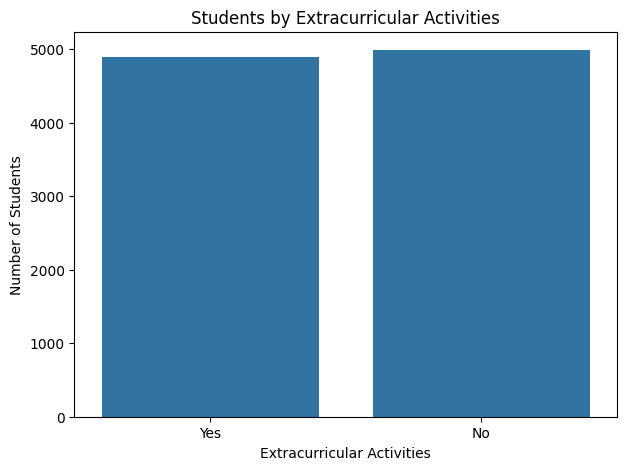

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Extracurricular Activities'
)

plt.title('Students by Extracurricular Activities')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Number of Students')

plt.show()

In [27]:
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [28]:
numerical_summary = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Minimum': df[numerical_columns].min(),
    'Maximum': df[numerical_columns].max(),
    'Standard Deviation': df[numerical_columns].std()
})
numerical_summary

,Mean,Median,Minimum,Maximum,Standard Deviation
Hours Studied,4.992100,5.0,1.0,9.0,2.589081
Previous Scores,69.441102,69.0,40.0,99.0,17.325601
Sleep Hours,6.531652,7.0,4.0,9.0,1.697683
Sample Question Papers Practiced,4.583004,5.0,0.0,9.0,2.867202
Performance Index,55.216651,55.0,10.0,100.0,19.208570


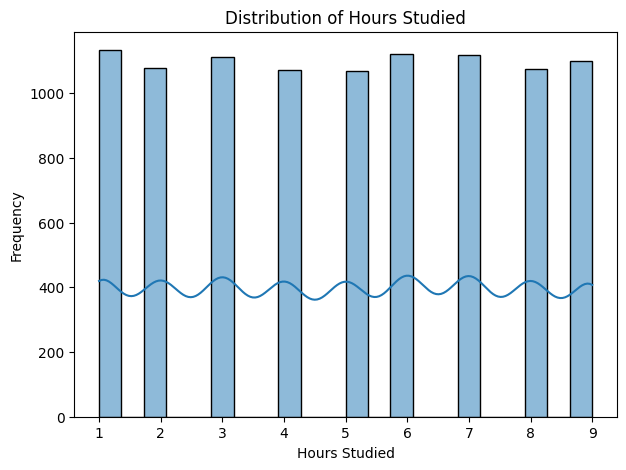

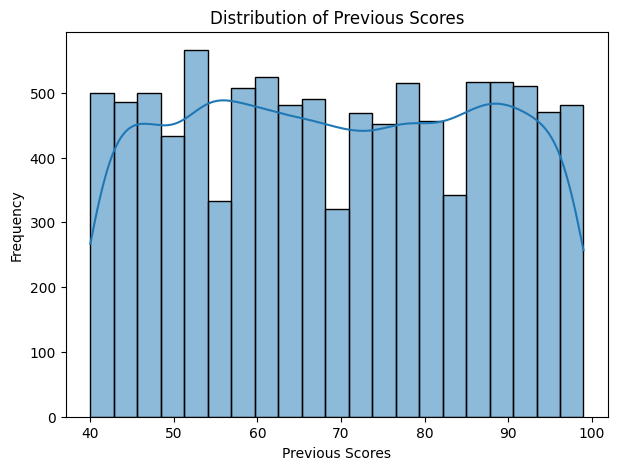

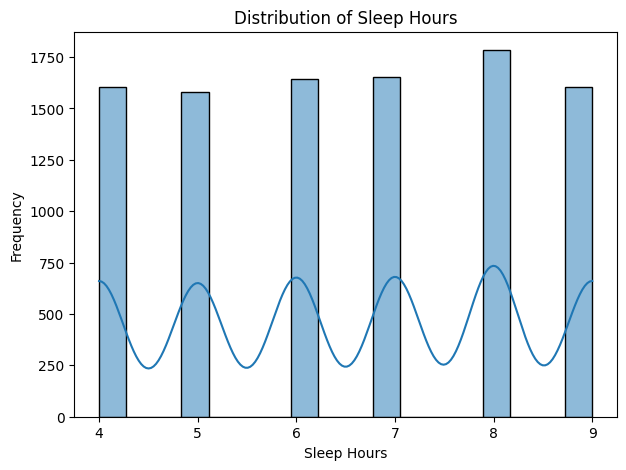

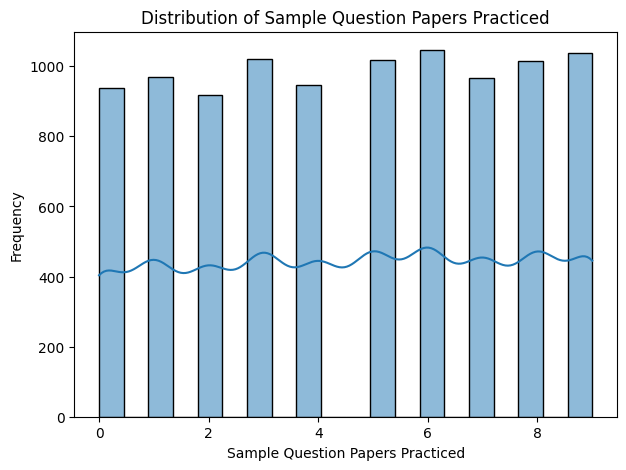

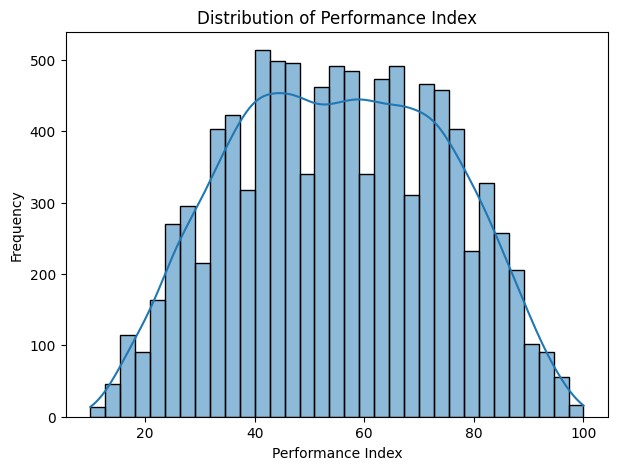

In [29]:
for col in numerical_columns:
    plt.figure(figsize=(7,5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

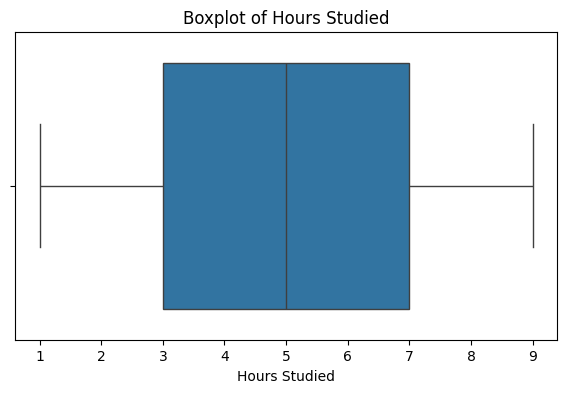

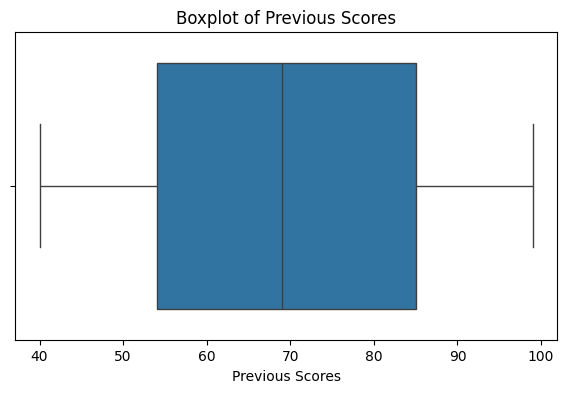

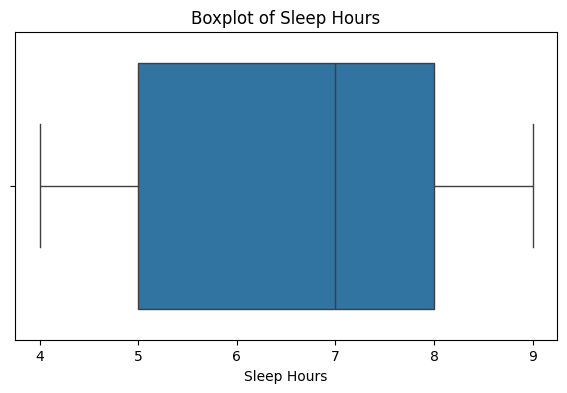

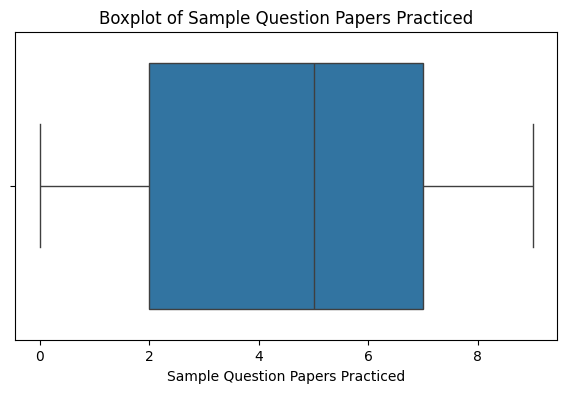

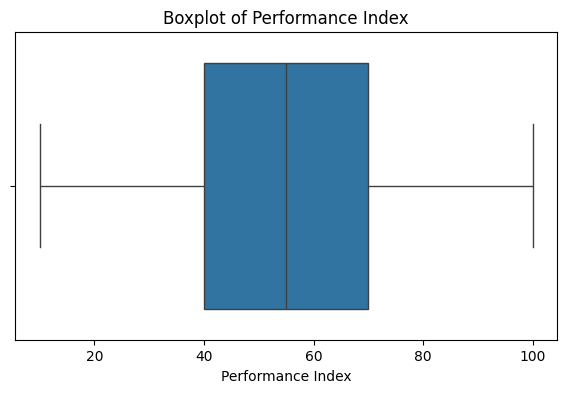

In [30]:
for col in numerical_columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [31]:
outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_table = pd.DataFrame(outlier_summary)
outlier_table

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Hours Studied,3.0,7.0,4.0,-3.0,13.0,0
1,Previous Scores,54.0,85.0,31.0,7.5,131.5,0
2,Sleep Hours,5.0,8.0,3.0,0.5,12.5,0
3,Sample Question Papers Practiced,2.0,7.0,5.0,-5.5,14.5,0
4,Performance Index,40.0,70.0,30.0,-5.0,115.0,0


In [32]:
print("Hours Studied:", df['Hours Studied'].min(), "to", df['Hours Studied'].max())
print("Previous Scores:", df['Previous Scores'].min(), "to", df['Previous Scores'].max())
print("Sleep Hours:", df['Sleep Hours'].min(), "to", df['Sleep Hours'].max())
print("Sample Question Papers Practiced:",
      df['Sample Question Papers Practiced'].min(),
      "to",
      df['Sample Question Papers Practiced'].max())
print("Performance Index:",
      df['Performance Index'].min(),
      "to",
      df['Performance Index'].max())

Hours Studied: 1 to 9
Previous Scores: 40 to 99
Sleep Hours: 4 to 9
Sample Question Papers Practiced: 0 to 9
Performance Index: 10.0 to 100.0


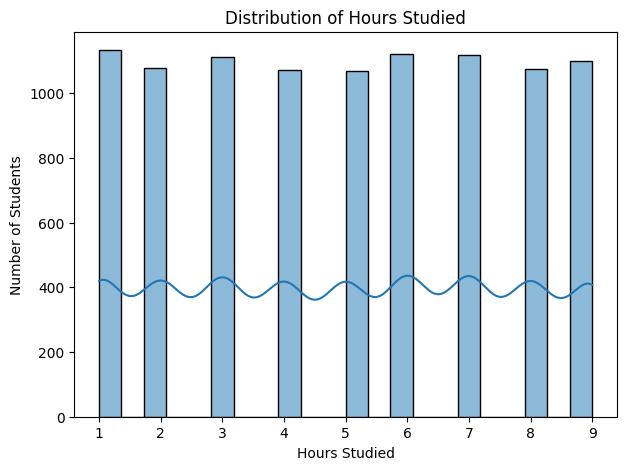

In [33]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Hours Studied', kde=True)
plt.title('Distribution of Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Number of Students')
plt.show()

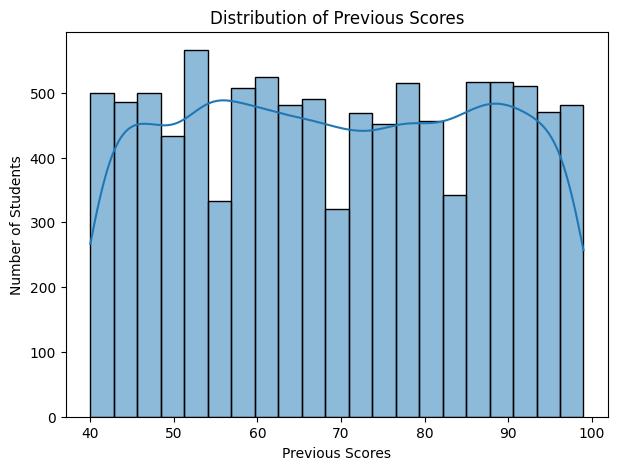

In [34]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Previous Scores', kde=True)
plt.title('Distribution of Previous Scores')
plt.xlabel('Previous Scores')
plt.ylabel('Number of Students')
plt.show()

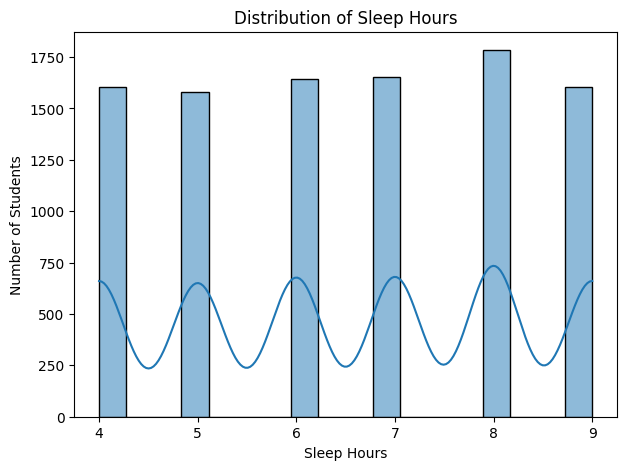

In [35]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Sleep Hours', kde=True)
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Number of Students')
plt.show()

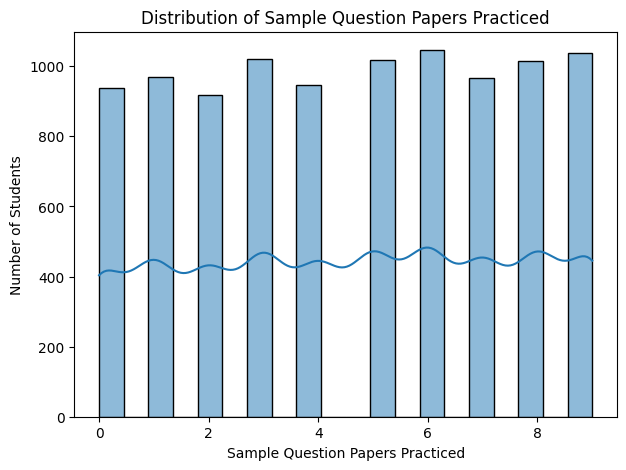

In [36]:
plt.figure(figsize=(7,5))
sns.histplot(
    data=df,
    x='Sample Question Papers Practiced',
    kde=True
)
plt.title('Distribution of Sample Question Papers Practiced')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Number of Students')
plt.show()

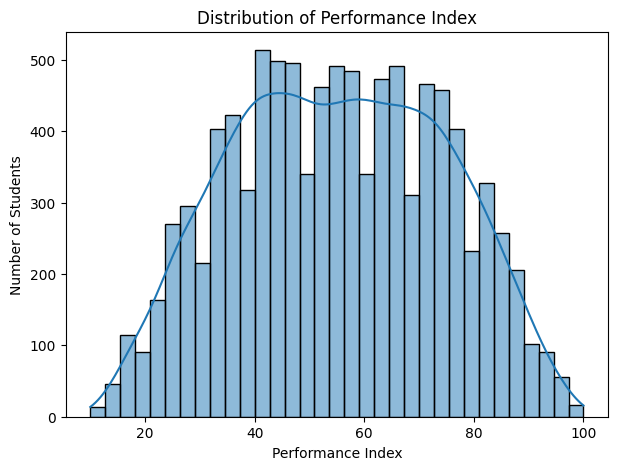

In [37]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Performance Index', kde=True)
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Number of Students')
plt.show()

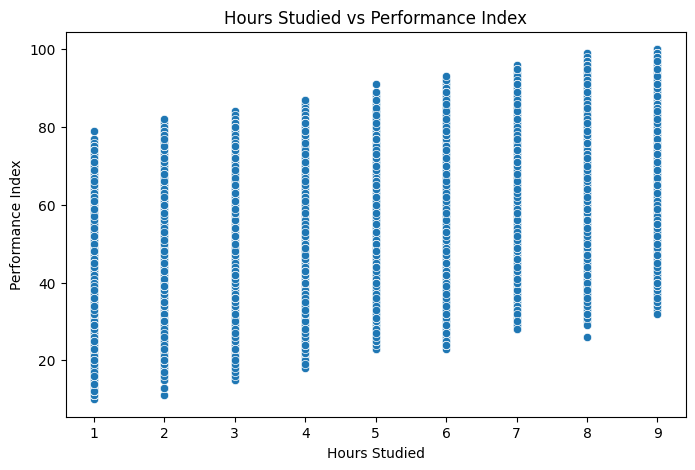

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Hours Studied',
    y='Performance Index'
)
plt.title('Hours Studied vs Performance Index')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.show()

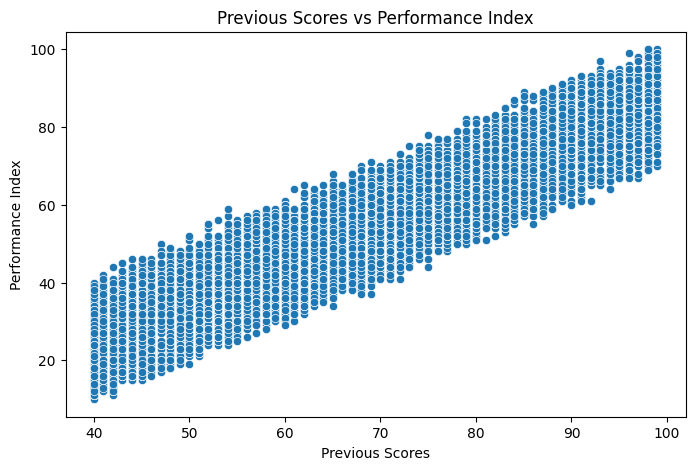

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Previous Scores',
    y='Performance Index'
)
plt.title('Previous Scores vs Performance Index')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.show()

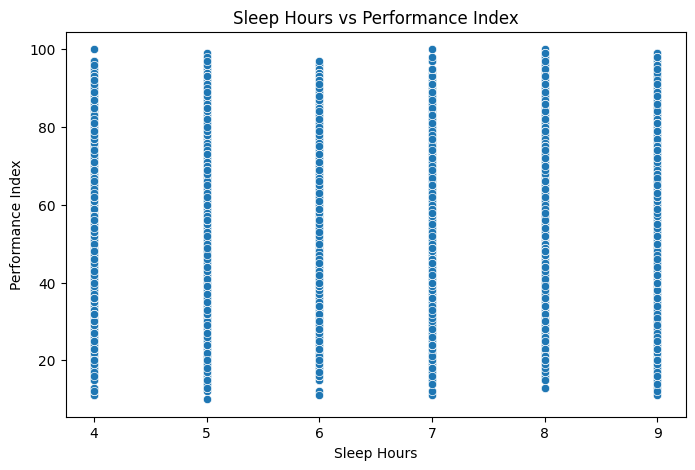

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Sleep Hours',
    y='Performance Index'
)
plt.title('Sleep Hours vs Performance Index')
plt.xlabel('Sleep Hours')
plt.ylabel('Performance Index')
plt.show()

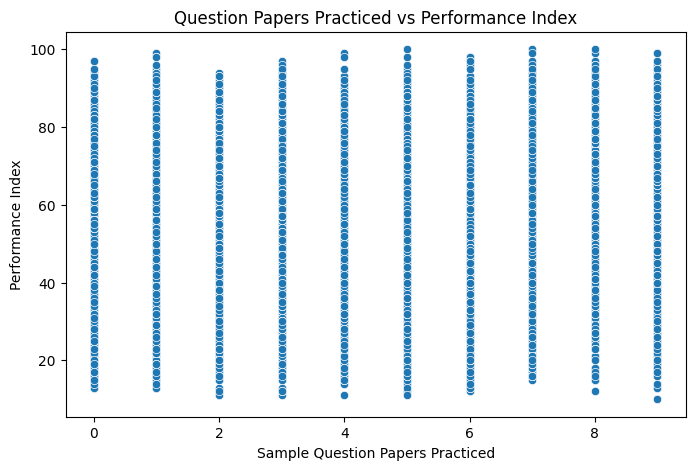

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Sample Question Papers Practiced',
    y='Performance Index'
)
plt.title('Question Papers Practiced vs Performance Index')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Performance Index')
plt.show()

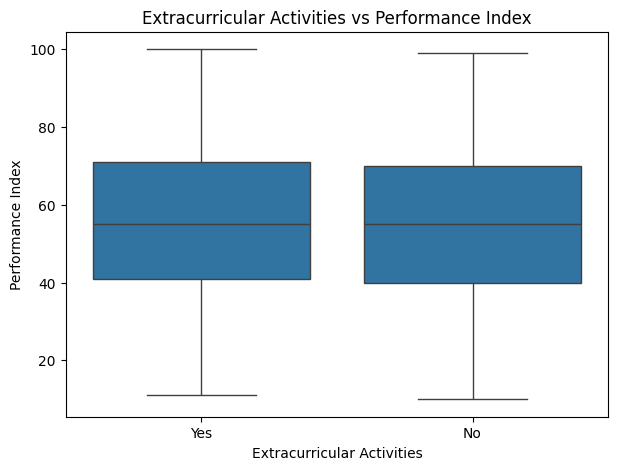

In [42]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='Extracurricular Activities',
    y='Performance Index'
)
plt.title('Extracurricular Activities vs Performance Index')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Performance Index')
plt.show()

In [43]:
correlation_with_performance = (
    df[numerical_columns]
    .corr()['Performance Index']
    .sort_values(ascending=False)
)

correlation_with_performance

,Performance Index
Performance Index,1.000000
Previous Scores,0.915135
Hours Studied,0.375332
Sleep Hours,0.050352
Sample Question Papers Practiced,0.043436


In [44]:
correlation_matrix = df[numerical_columns].corr()
correlation_matrix

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.007975,0.008719,0.915135
Sleep Hours,0.002131,0.007975,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.050352,0.043436,1.000000


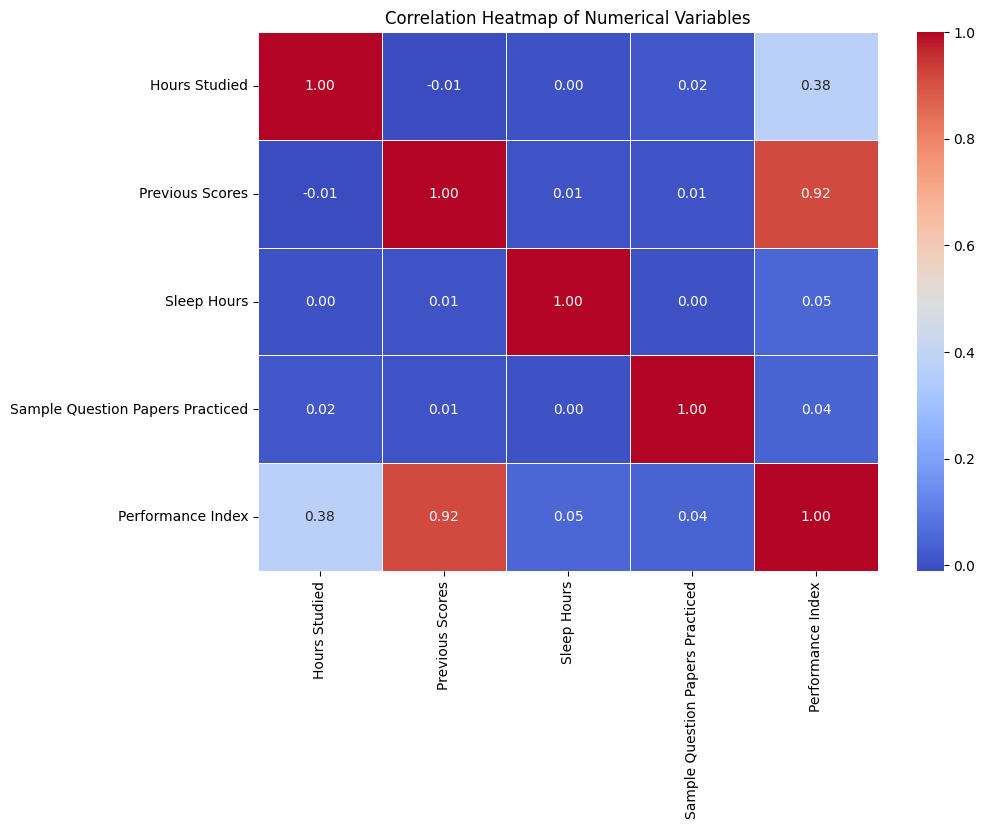

In [45]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

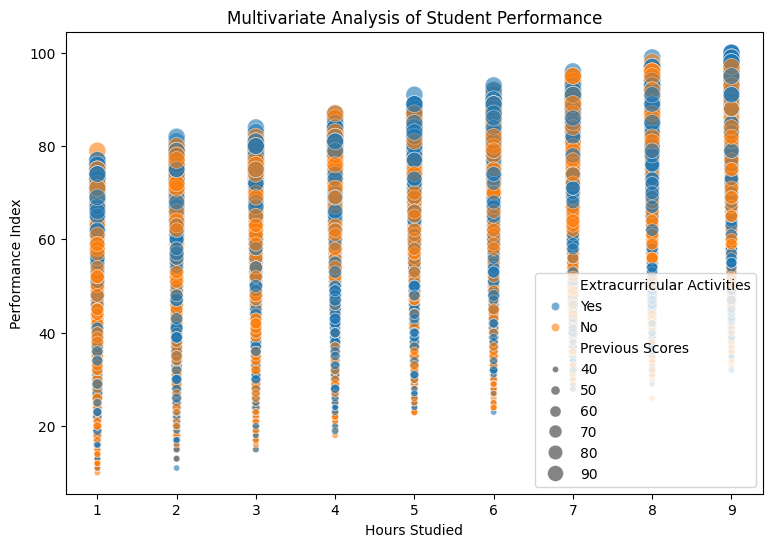

In [46]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Hours Studied',
    y='Performance Index',
    hue='Extracurricular Activities',
    size='Previous Scores',
    sizes=(20,150),
    alpha=0.6
)

plt.title('Multivariate Analysis of Student Performance')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.show()

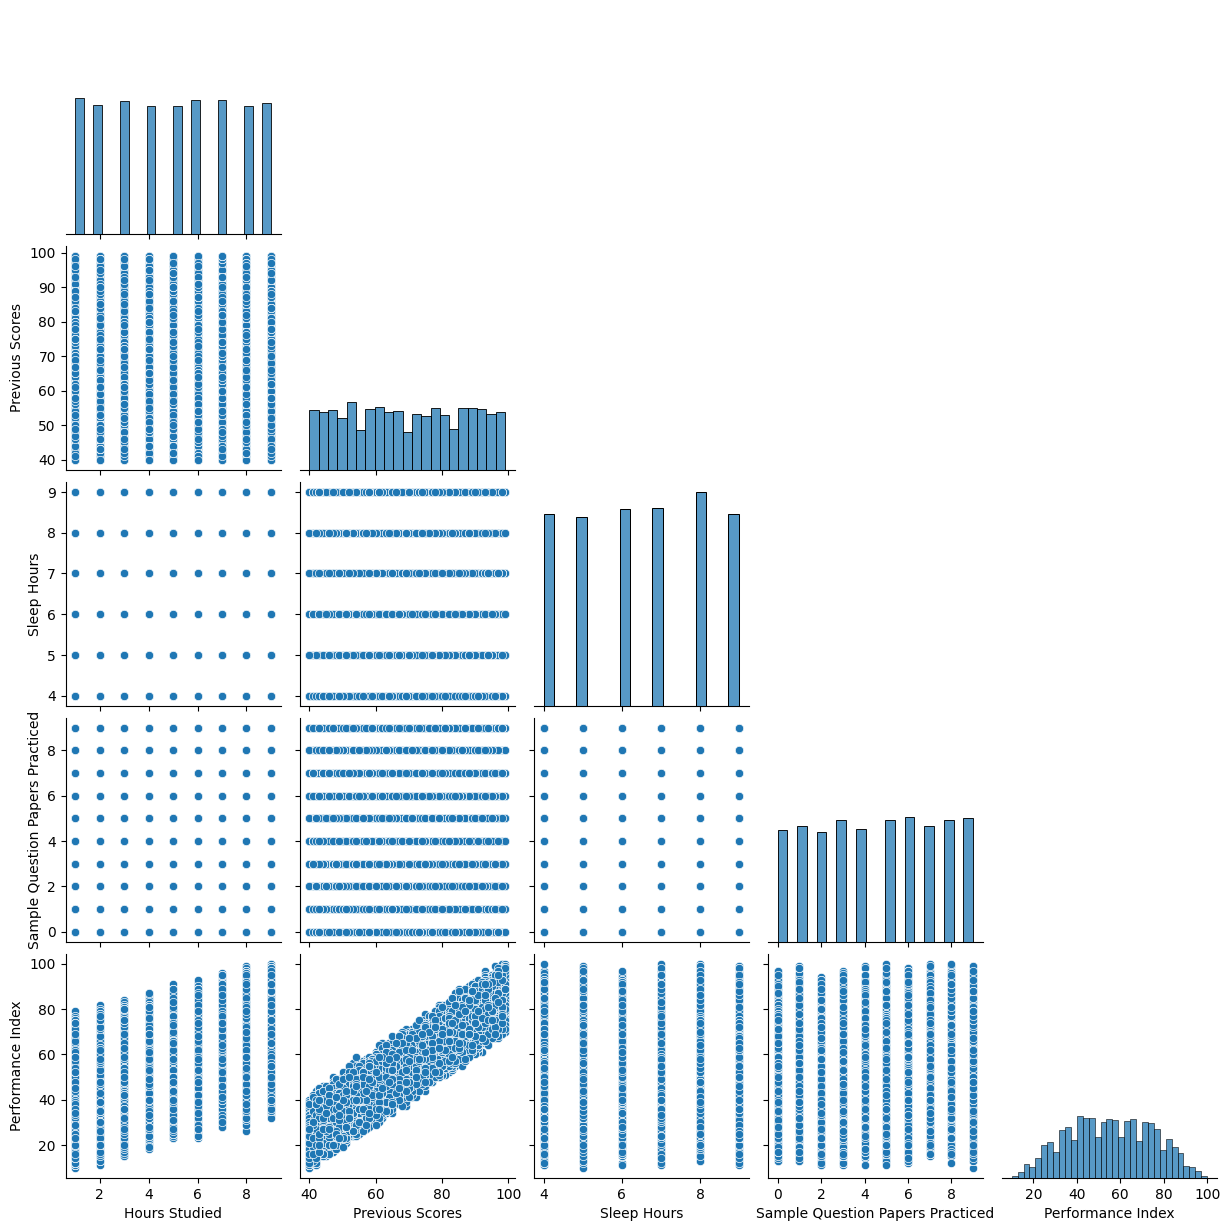

In [47]:
selected_columns = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'
]

sns.pairplot(
    df[selected_columns],
    corner=True
)

plt.show()

In [48]:
print("Average Hours Studied:",
      round(df['Hours Studied'].mean(), 2))

print("Average Previous Score:",
      round(df['Previous Scores'].mean(), 2))

print("Average Sleep Hours:",
      round(df['Sleep Hours'].mean(), 2))

print("Average Question Papers Practiced:",
      round(df['Sample Question Papers Practiced'].mean(), 2))

print("Average Performance Index:",
      round(df['Performance Index'].mean(), 2))

Average Hours Studied: 4.99
Average Previous Score: 69.44
Average Sleep Hours: 6.53
Average Question Papers Practiced: 4.58
Average Performance Index: 55.22


In [49]:
print("Highest Performance Index:",
      df['Performance Index'].max())

print("Lowest Performance Index:",
      df['Performance Index'].min())

Highest Performance Index: 100.0
Lowest Performance Index: 10.0


In [50]:
activity_performance = (
    df.groupby('Extracurricular Activities')['Performance Index']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

activity_performance

,count,mean,median,min,max
Extracurricular Activities,,,,,
No,4986,54.720818,55.0,10.0,99.0
Yes,4887,55.722529,55.0,11.0,100.0


In [51]:
df_clean = df.copy()

df_clean

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [52]:
print("Final DataFrame:", df_clean.shape)
print("Missing Values:", df_clean.isnull().sum().sum())
print("Duplicate Rows:", df_clean.duplicated().sum())

Final DataFrame: (9873, 6)
Missing Values: 0
Duplicate Rows: 0


In [53]:
df_clean.to_csv(
    '/content/Student_Performance_Cleaned.csv',
    index=False
)

print("Student_Performance_Cleaned.csv saved successfully.")

Student_Performance_Cleaned.csv saved successfully.
